In [ ]:
!pip install networkx

In [ ]:
import pandas as pd
import networkx as nx

df = pd.read_excel("witvliet_2020_8.xlsx")

# Build directed graph
G_directed = nx.DiGraph()

for _, row in df.iterrows():
    pre = row["pre"]
    post = row["post"]
    weight = row["synapses"]

    # accumulate weights if multiple entries
    if G_directed.has_edge(pre, post):
        G_directed[pre][post]["weight"] += weight
    else:
        G_directed.add_edge(pre, post, weight=weight)

print("Directed Nodes:", G_directed.number_of_nodes())
print("Directed Edges:", G_directed.number_of_edges())

Directed Nodes: 219
Directed Edges: 2416


In [ ]:
G = G_directed.to_undirected()

# If disconnected, use largest component
if not nx.is_connected(G):
    largest_cc = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest_cc).copy()

print("Undirected Nodes:", G.number_of_nodes())
print("Undirected Edges:", G.number_of_edges())

Undirected Nodes: 219
Undirected Edges: 2061


In [ ]:
import random
import numpy as np

# Precompute shortest paths
shortest = dict(nx.all_pairs_shortest_path_length(G))

def compute_delta(samples=2000):
    nodes = list(G.nodes())
    deltas = []

    for _ in range(samples):
        a, b, c, d = random.sample(nodes, 4)

        s1 = shortest[a][b] + shortest[c][d]
        s2 = shortest[a][c] + shortest[b][d]
        s3 = shortest[a][d] + shortest[b][c]

        sums = sorted([s1, s2, s3])
        delta = 0.5 * (sums[2] - sums[1])
        deltas.append(delta)

    return np.mean(deltas)

delta = compute_delta()
diameter = nx.diameter(G)

print("Mean δ:", delta)
print("Diameter:", diameter)
print("Relative δ:", delta/diameter)

Mean δ: 0.23875
Diameter: 5
Relative δ: 0.04775


In [ ]:
!pip install geoopt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 3.5 MB/s eta 0:00:00


In [ ]:
import torch
import geoopt
import numpy as np
import networkx as nx
from sklearn.metrics import roc_auc_score

# Use undirected G from previous experiment
nodes = list(G.nodes())
node_index = {node:i for i,node in enumerate(nodes)}
n = len(nodes)

# Create adjacency matrix
A = np.zeros((n,n))
for u,v,data in G.edges(data=True):
    i = node_index[u]
    j = node_index[v]
    A[i,j] = 1
    A[j,i] = 1

A = torch.tensor(A, dtype=torch.float)

# Hyperbolic manifold
manifold = geoopt.PoincareBall(c=1.0)

# 2D embedding is enough for visualization
z = geoopt.ManifoldParameter(
    torch.randn(n, 2) * 0.01,
    manifold=manifold
)

optimizer = geoopt.optim.RiemannianAdam([z], lr=0.01)

# Train to reconstruct adjacency
for epoch in range(1000):
    optimizer.zero_grad()

    dists = manifold.dist(z.unsqueeze(1), z.unsqueeze(0))
    recon = torch.exp(-dists)

    loss = ((recon - A)**2).mean()

    loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        print("Epoch", epoch, "Loss:", loss.item())

Epoch 0 Loss: 0.8534437417984009
Epoch 200 Loss: 0.1629556566476822
Epoch 400 Loss: 0.11616389453411102
Epoch 600 Loss: 0.10045814514160156
Epoch 800 Loss: 0.09261337667703629


In [ ]:
# Compute radius (Euclidean norm inside Poincaré ball)
radii = torch.norm(z, dim=1).detach().numpy()

# Compute degree
degrees = np.array([G.degree(node) for node in nodes])

# Correlation
corr = np.corrcoef(radii, degrees)[0,1]

print("Correlation radius vs degree:", corr)

Correlation radius vs degree: -0.7500278135039339


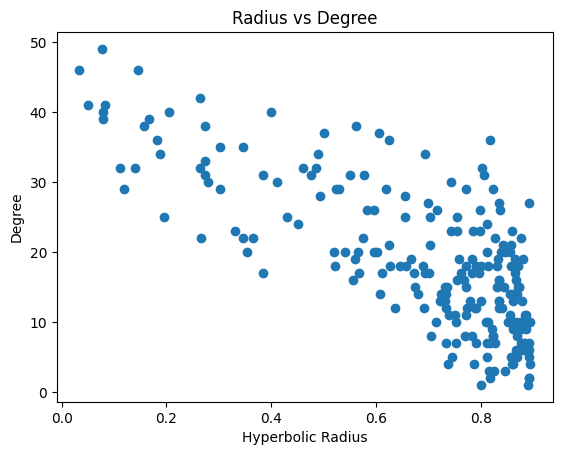

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(radii, degrees)
plt.xlabel("Hyperbolic Radius")
plt.ylabel("Degree")
plt.title("Radius vs Degree")
plt.show()

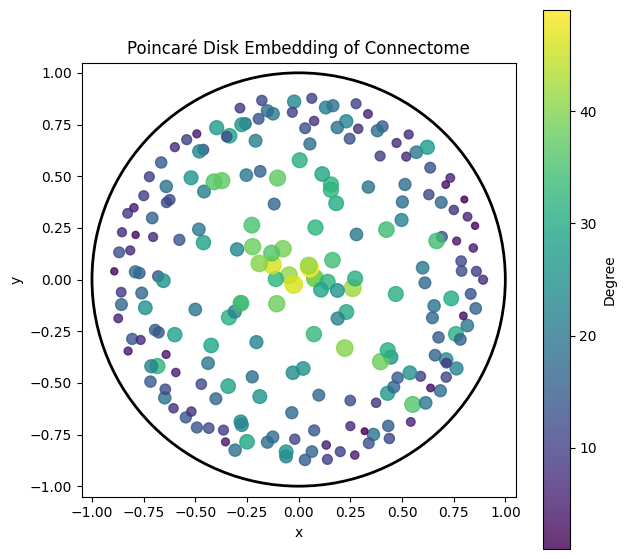

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract coordinates
coords = z.detach().numpy()

# Degree array
degrees = np.array([G.degree(node) for node in nodes])

# Normalize degrees for color scaling
deg_norm = (degrees - degrees.min()) / (degrees.max() - degrees.min())

plt.figure(figsize=(7,7))

# Draw unit circle (Poincaré boundary)
circle = plt.Circle((0, 0), 1, color='black', fill=False, linewidth=2)
plt.gca().add_artist(circle)

# Scatter plot
plt.scatter(coords[:,0], coords[:,1],
            c=degrees,
            cmap='viridis',
            s=20 + 3*degrees,   # size scaled by degree
            alpha=0.8)

plt.colorbar(label="Degree")
plt.xlim(-1.05,1.05)
plt.ylim(-1.05,1.05)
plt.gca().set_aspect('equal', 'box')
plt.title("Poincaré Disk Embedding of Connectome")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [ ]:
!pip install geoopt

In [ ]:
import pandas as pd
import networkx as nx
import torch
import geoopt
import numpy as np
import random
import os

In [ ]:
def build_graph(filepath):
    df = pd.read_excel(filepath)

    G = nx.DiGraph()

    for _, row in df.iterrows():
        pre = row["pre"]
        post = row["post"]
        weight = row["synapses"]

        if G.has_edge(pre, post):
            G[pre][post]["weight"] += weight
        else:
            G.add_edge(pre, post, weight=weight)

    G = G.to_undirected()

    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()

    return G

In [ ]:
def compute_delta(G, samples=1000):
    shortest = dict(nx.all_pairs_shortest_path_length(G))
    nodes = list(G.nodes())
    deltas = []

    for _ in range(samples):
        a,b,c,d = random.sample(nodes, 4)

        s1 = shortest[a][b] + shortest[c][d]
        s2 = shortest[a][c] + shortest[b][d]
        s3 = shortest[a][d] + shortest[b][c]

        sums = sorted([s1,s2,s3])
        delta = 0.5*(sums[2] - sums[1])
        deltas.append(delta)

    return np.mean(deltas)

In [ ]:
def hyperbolic_embedding(G, dim=2, epochs=600):

    nodes = list(G.nodes())
    node_index = {node:i for i,node in enumerate(nodes)}
    n = len(nodes)

    A = np.zeros((n,n))
    for u,v in G.edges():
        i = node_index[u]
        j = node_index[v]
        A[i,j] = 1
        A[j,i] = 1

    A = torch.tensor(A, dtype=torch.float)

    manifold = geoopt.PoincareBall(c=1.0)

    z = geoopt.ManifoldParameter(
        torch.randn(n, dim) * 0.01,
        manifold=manifold
    )

    optimizer = geoopt.optim.RiemannianAdam([z], lr=0.01)

    for epoch in range(epochs):
        optimizer.zero_grad()
        dists = manifold.dist(z.unsqueeze(1), z.unsqueeze(0))
        recon = torch.exp(-dists)
        loss = ((recon - A)**2).mean()
        loss.backward()
        optimizer.step()

    radii = torch.norm(z, dim=1).detach().numpy()
    degrees = np.array([G.degree(node) for node in nodes])
    corr = np.corrcoef(radii, degrees)[0,1]

    return radii, corr

In [ ]:
results = []

for stage in range(1,9):

    file = f"witvliet_2020_{stage}.xlsx"

    print("Processing stage", stage)

    G = build_graph(file)

    delta = compute_delta(G)
    diameter = nx.diameter(G)
    rel_delta = delta / diameter

    radii, corr = hyperbolic_embedding(G)

    results.append({
        "stage": stage,
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "rel_delta": rel_delta,
        "radial_corr": corr,
        "mean_radius": np.mean(radii),
        "radius_var": np.var(radii)
    })

Processing stage 1
Processing stage 2
Processing stage 3
Processing stage 4
Processing stage 5
Processing stage 6
Processing stage 7
Processing stage 8


   stage  nodes  edges  rel_delta  radial_corr  mean_radius  radius_var
0      1    187    782   0.042143    -0.457431     0.648229    0.030716
1      2    194    995   0.045917    -0.512008     0.642001    0.032920
2      3    198    990   0.047000    -0.302327     0.646350    0.030117
3      4    204   1193   0.044333    -0.605014     0.633591    0.034916
4      5    211   1561   0.050900    -0.595216     0.629666    0.033780
5      6    216   1540   0.053900    -0.681496     0.627266    0.037518
6      7    222   2133   0.047000    -0.655288     0.615776    0.039252
7      8    219   2061   0.046700    -0.718846     0.612806    0.037924


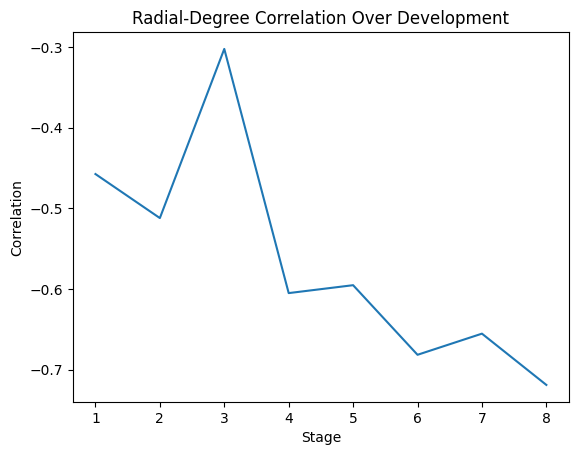

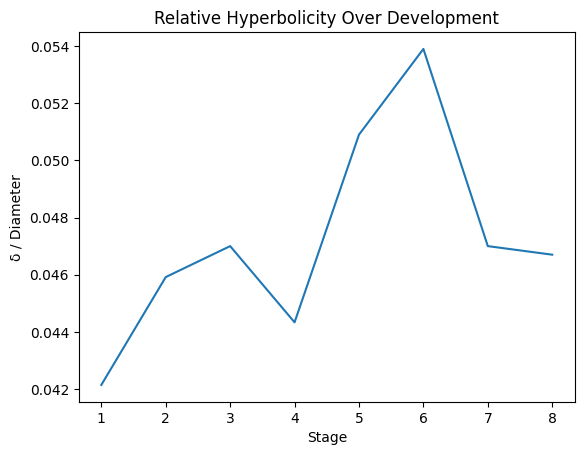

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_results = pd.DataFrame(results)
print(df_results)

plt.plot(df_results["stage"], df_results["radial_corr"])
plt.title("Radial-Degree Correlation Over Development")
plt.xlabel("Stage")
plt.ylabel("Correlation")
plt.show()

plt.plot(df_results["stage"], df_results["rel_delta"])
plt.title("Relative Hyperbolicity Over Development")
plt.xlabel("Stage")
plt.ylabel("δ / Diameter")
plt.show()

Experiment: Radial Trajectories of Individual Neurons Across Development

In [ ]:
import pandas as pd
import networkx as nx
import torch
import geoopt
import numpy as np

def get_stage_radii(stage, dim=2, epochs=600):

    file = f"witvliet_2020_{stage}.xlsx"
    df = pd.read_excel(file)

    G = nx.DiGraph()
    for _, row in df.iterrows():
        pre = row["pre"]
        post = row["post"]
        weight = row["synapses"]

        if G.has_edge(pre, post):
            G[pre][post]["weight"] += weight
        else:
            G.add_edge(pre, post, weight=weight)

    G = G.to_undirected()
    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()

    nodes = list(G.nodes())
    node_index = {node:i for i,node in enumerate(nodes)}
    n = len(nodes)

    A = np.zeros((n,n))
    for u,v in G.edges():
        i = node_index[u]
        j = node_index[v]
        A[i,j] = 1
        A[j,i] = 1

    A = torch.tensor(A, dtype=torch.float)

    manifold = geoopt.PoincareBall(c=1.0)

    z = geoopt.ManifoldParameter(
        torch.randn(n, dim) * 0.01,
        manifold=manifold
    )

    optimizer = geoopt.optim.RiemannianAdam([z], lr=0.01)

    for epoch in range(epochs):
        optimizer.zero_grad()
        dists = manifold.dist(z.unsqueeze(1), z.unsqueeze(0))
        recon = torch.exp(-dists)
        loss = ((recon - A)**2).mean()
        loss.backward()
        optimizer.step()

    radii = torch.norm(z, dim=1).detach().numpy()

    return dict(zip(nodes, radii))

In [ ]:
all_radii = {}

for stage in range(1,9):
    print("Computing stage", stage)
    stage_radii = get_stage_radii(stage)

    for neuron, r in stage_radii.items():
        if neuron not in all_radii:
            all_radii[neuron] = {}
        all_radii[neuron][stage] = r

Computing stage 1
Computing stage 2
Computing stage 3
Computing stage 4
Computing stage 5
Computing stage 6
Computing stage 7
Computing stage 8


In [ ]:
# Load adult graph (stage 8)
file = "witvliet_2020_8.xlsx"
df = pd.read_excel(file)

G8 = nx.DiGraph()
for _, row in df.iterrows():
    G8.add_edge(row["pre"], row["post"])

G8 = G8.to_undirected()

degrees = dict(G8.degree())

# Top 10 hubs
top_hubs = sorted(degrees, key=degrees.get, reverse=True)[:10]
print("Top hubs:", top_hubs)

Top hubs: ['AVEL', 'AIBL', 'AIBR', 'RMDL', 'AVER', 'RIBR', 'RIML', 'RIAR', 'RIBL', 'AVAL']


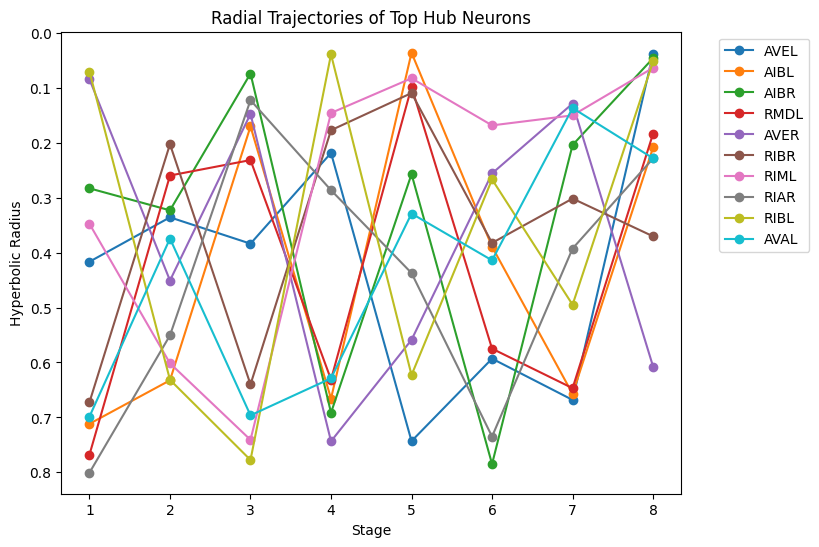

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for neuron in top_hubs:
    stages = sorted(all_radii[neuron].keys())
    radii = [all_radii[neuron][s] for s in stages]

    plt.plot(stages, radii, marker='o', label=neuron)

plt.gca().invert_yaxis()  # inward movement = downward visually
plt.xlabel("Stage")
plt.ylabel("Hyperbolic Radius")
plt.title("Radial Trajectories of Top Hub Neurons")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

Incremental Hyperbolic Embedding Across Development

In [ ]:
import pandas as pd
import networkx as nx
import torch
import geoopt
import numpy as np

def build_graph(stage):
    file = f"witvliet_2020_{stage}.xlsx"
    df = pd.read_excel(file)

    G = nx.DiGraph()
    for _, row in df.iterrows():
        pre = row["pre"]
        post = row["post"]
        weight = row["synapses"]

        if G.has_edge(pre, post):
            G[pre][post]["weight"] += weight
        else:
            G.add_edge(pre, post, weight=weight)

    G = G.to_undirected()

    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()

    return G

In [ ]:
manifold = geoopt.PoincareBall(c=1.0)

prev_embeddings = None
prev_nodes = None

all_radii_incremental = {}

for stage in range(1,9):

    print("Processing stage", stage)

    G = build_graph(stage)
    nodes = list(G.nodes())
    n = len(nodes)

    node_index = {node:i for i,node in enumerate(nodes)}

    # Build adjacency
    A = np.zeros((n,n))
    for u,v in G.edges():
        i = node_index[u]
        j = node_index[v]
        A[i,j] = 1
        A[j,i] = 1

    A = torch.tensor(A, dtype=torch.float)

    # --- Initialize embeddings ---

    if prev_embeddings is None:
        # Stage 1 random initialization
        z = geoopt.ManifoldParameter(
            torch.randn(n, 2) * 0.01,
            manifold=manifold
        )
    else:
        # Stage >1
        z_init = torch.randn(n, 2) * 0.01

        for i,node in enumerate(nodes):
            if node in prev_nodes:
                old_index = prev_nodes.index(node)
                z_init[i] = prev_embeddings[old_index].detach()

        z = geoopt.ManifoldParameter(z_init, manifold=manifold)

    optimizer = geoopt.optim.RiemannianAdam([z], lr=0.01)

    # --- Train ---

    for epoch in range(600):
        optimizer.zero_grad()

        dists = manifold.dist(z.unsqueeze(1), z.unsqueeze(0))
        recon = torch.exp(-dists)

        loss = ((recon - A)**2).mean()
        loss.backward()
        optimizer.step()

    # --- Store radii ---

    radii = torch.norm(z, dim=1).detach().numpy()

    for i,node in enumerate(nodes):
        if node not in all_radii_incremental:
            all_radii_incremental[node] = {}
        all_radii_incremental[node][stage] = radii[i]

    # Save for next stage
    prev_embeddings = z.detach()
    prev_nodes = nodes

Processing stage 1
Processing stage 2
Processing stage 3
Processing stage 4
Processing stage 5
Processing stage 6
Processing stage 7
Processing stage 8


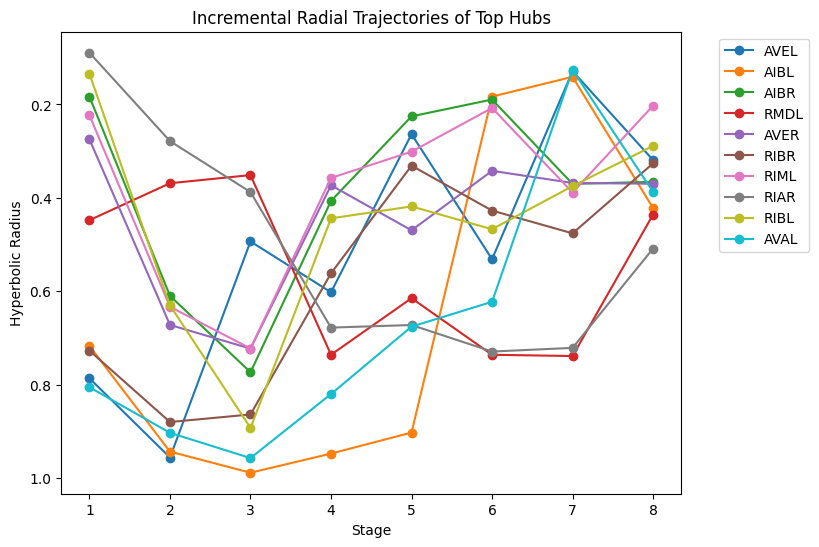

In [ ]:
# Identify adult hubs
G8 = build_graph(8)
degrees = dict(G8.degree())
top_hubs = sorted(degrees, key=degrees.get, reverse=True)[:10]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for neuron in top_hubs:
    if neuron in all_radii_incremental:
        stages = sorted(all_radii_incremental[neuron].keys())
        radii = [all_radii_incremental[neuron][s] for s in stages]
        plt.plot(stages, radii, marker='o', label=neuron)

plt.gca().invert_yaxis()
plt.xlabel("Stage")
plt.ylabel("Hyperbolic Radius")
plt.title("Incremental Radial Trajectories of Top Hubs")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

Local Interpolation (3 & 5 → 4)

In [ ]:
import pandas as pd
import networkx as nx
import torch
import geoopt
import numpy as np
from sklearn.metrics import roc_auc_score

In [ ]:
def build_graph(stage):
    file = f"witvliet_2020_{stage}.xlsx"
    df = pd.read_excel(file)

    G = nx.DiGraph()
    for _, row in df.iterrows():
        G.add_edge(row["pre"], row["post"])

    G = G.to_undirected()

    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()

    return G

In [ ]:
G3 = build_graph(3)
G4 = build_graph(4)
G5 = build_graph(5)

common_nodes = list(set(G3.nodes()) & set(G4.nodes()) & set(G5.nodes()))

G3 = G3.subgraph(common_nodes)
G4 = G4.subgraph(common_nodes)
G5 = G5.subgraph(common_nodes)

nodes = list(common_nodes)

print("Common nodes:", len(nodes))

Common nodes: 195


In [ ]:
def graph_to_adj(G, nodes):
    n = len(nodes)
    index = {node:i for i,node in enumerate(nodes)}

    A = np.zeros((n,n))
    for u,v in G.edges():
        if u in index and v in index:
            i = index[u]
            j = index[v]
            A[i,j] = 1
            A[j,i] = 1

    return torch.tensor(A, dtype=torch.float)

A3 = graph_to_adj(G3, nodes)
A4 = graph_to_adj(G4, nodes)
A5 = graph_to_adj(G5, nodes)

In [ ]:
def train_euclidean(A, dim=2, epochs=800, z_init=None):
    n = A.shape[0]

    if z_init is None:
        z = torch.nn.Parameter(torch.randn(n, dim)*0.01)
    else:
        z = torch.nn.Parameter(z_init.clone().detach())

    optimizer = torch.optim.Adam([z], lr=0.01)

    for epoch in range(epochs):
        optimizer.zero_grad()
        dists = torch.cdist(z, z)
        recon = torch.exp(-dists)
        loss = ((recon - A)**2).mean()
        loss.backward()
        optimizer.step()

    return z.detach()

In [ ]:
z3_e = train_euclidean(A3)
z5_e = train_euclidean(A5, z_init=z3_e)

In [ ]:
z4_e_interp = 0.5 * (z3_e + z5_e)

dists_e = torch.cdist(z4_e_interp, z4_e_interp)
A4_pred_e = torch.exp(-dists_e).detach().numpy()

In [ ]:
def train_hyperbolic(A, manifold, dim=2, epochs=800, z_init=None):
    n = A.shape[0]

    if z_init is None:
        z = geoopt.ManifoldParameter(
            torch.randn(n, dim)*0.01,
            manifold=manifold
        )
    else:
        z = geoopt.ManifoldParameter(
            z_init.clone().detach(),
            manifold=manifold
        )

    optimizer = geoopt.optim.RiemannianAdam([z], lr=0.01)

    for epoch in range(epochs):
        optimizer.zero_grad()
        dists = manifold.dist(z.unsqueeze(1), z.unsqueeze(0))
        recon = torch.exp(-dists)
        loss = ((recon - A)**2).mean()
        loss.backward()
        optimizer.step()

    return z.detach()

In [ ]:
manifold = geoopt.PoincareBall(c=1.0)

z3_h = train_hyperbolic(A3, manifold)
z5_h = train_hyperbolic(A5, manifold, z_init=z3_h)

In [ ]:
t = torch.tensor(0.5, device=z3_h.device)

diff = manifold.mobius_add(-z3_h, z5_h)
scaled = manifold.mobius_scalar_mul(t, diff)
z4_h_interp = manifold.mobius_add(z3_h, scaled)

dists_h = manifold.dist(
    z4_h_interp.unsqueeze(1),
    z4_h_interp.unsqueeze(0)
)

A4_pred_h = torch.exp(-dists_h).detach().numpy()

In [ ]:
def evaluate_auc(A_true, A_pred):
    A_true = A_true.numpy()
    mask = np.triu(np.ones(A_true.shape), k=1).astype(bool)

    y_true = A_true[mask]
    y_score = A_pred[mask]

    return roc_auc_score(y_true, y_score)

In [ ]:
auc_e = evaluate_auc(A4, A4_pred_e)
auc_h = evaluate_auc(A4, A4_pred_h)

print("Euclidean AUC:", auc_e)
print("Hyperbolic AUC:", auc_h)

Euclidean AUC: 0.6756737312003798
Hyperbolic AUC: 0.6544200698666167


New Edge Formation vs Hyperbolic Distance

In [ ]:
dists_stage3 = manifold.dist(
    z3_h.unsqueeze(1),
    z3_h.unsqueeze(0)
).detach().numpy()

In [ ]:
A3_np = A3.numpy()
A4_np = A4.numpy()

# New edges: present in stage 4 but not in stage 3
new_edges = (A4_np == 1) & (A3_np == 0)

In [ ]:
mask = np.triu(np.ones(A3_np.shape), k=1).astype(bool)

distances = dists_stage3[mask]
labels = new_edges[mask]  # 1 if new edge formed

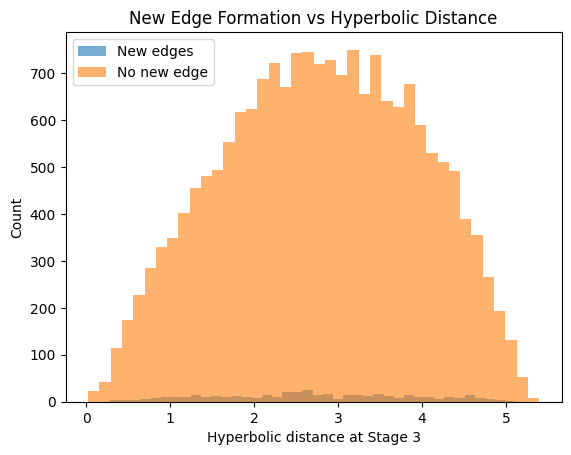

AUC for predicting new edges using hyperbolic distance: 0.519021771091096


In [ ]:
import matplotlib.pyplot as plt

plt.hist(distances[labels==1], bins=40, alpha=0.6, label="New edges")
plt.hist(distances[labels==0], bins=40, alpha=0.6, label="No new edge")
plt.legend()
plt.xlabel("Hyperbolic distance at Stage 3")
plt.ylabel("Count")
plt.title("New Edge Formation vs Hyperbolic Distance")
plt.show()

from sklearn.metrics import roc_auc_score

# Use negative distance (closer = higher probability)
auc_growth = roc_auc_score(labels, -distances)

print("AUC for predicting new edges using hyperbolic distance:", auc_growth)

In [ ]:
import pandas as pd
import networkx as nx
import torch
import geoopt
import numpy as np
from sklearn.metrics import roc_auc_score

# ----------------------------
# 1. Helper: Build Graph
# ----------------------------
def build_graph(stage):
    file = f"witvliet_2020_{stage}.xlsx"
    df = pd.read_excel(file)

    G = nx.DiGraph()
    for _, row in df.iterrows():
        G.add_edge(row["pre"], row["post"])

    G = G.to_undirected()

    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()

    return G

# ----------------------------
# 2. Convert Graph to Adjacency
# ----------------------------
def graph_to_adj(G, nodes):
    n = len(nodes)
    index = {node:i for i,node in enumerate(nodes)}

    A = np.zeros((n,n))
    for u,v in G.edges():
        if u in index and v in index:
            i = index[u]
            j = index[v]
            A[i,j] = 1
            A[j,i] = 1

    return torch.tensor(A, dtype=torch.float)

# ----------------------------
# 3. Hyperbolic Training
# ----------------------------
def train_hyperbolic(A, manifold, dim=2, epochs=600, z_init=None):
    n = A.shape[0]

    if z_init is None:
        z = geoopt.ManifoldParameter(
            torch.randn(n, dim)*0.01,
            manifold=manifold
        )
    else:
        z = geoopt.ManifoldParameter(
            z_init.clone().detach(),
            manifold=manifold
        )

    optimizer = geoopt.optim.RiemannianAdam([z], lr=0.01)

    for epoch in range(epochs):
        optimizer.zero_grad()
        dists = manifold.dist(z.unsqueeze(1), z.unsqueeze(0))
        recon = torch.exp(-dists)
        loss = ((recon - A)**2).mean()
        loss.backward()
        optimizer.step()

    return z.detach()

# ----------------------------
# 4. Euclidean Training
# ----------------------------
def train_euclidean(A, dim=2, epochs=600, z_init=None):
    n = A.shape[0]

    if z_init is None:
        z = torch.nn.Parameter(torch.randn(n, dim)*0.01)
    else:
        z = torch.nn.Parameter(z_init.clone().detach())

    optimizer = torch.optim.Adam([z], lr=0.01)

    for epoch in range(epochs):
        optimizer.zero_grad()
        dists = torch.cdist(z, z)
        recon = torch.exp(-dists)
        loss = ((recon - A)**2).mean()
        loss.backward()
        optimizer.step()

    return z.detach()

# ----------------------------
# 5. Run Across All Transitions
# ----------------------------

manifold = geoopt.PoincareBall(c=1.0)

prev_z_h = None
prev_z_e = None
prev_nodes = None
prev_A = None

results = []

for stage in range(1,9):

    print(f"Processing Stage {stage}")

    G = build_graph(stage)
    nodes = list(G.nodes())
    A = graph_to_adj(G, nodes)

    # --- ALIGN WITH PREVIOUS STAGE ---

    if prev_z_h is None:
        # Stage 1
        z_h = train_hyperbolic(A, manifold)
        z_e = train_euclidean(A)
    else:
        # align nodes
        common_nodes = list(set(prev_nodes) & set(nodes))

        idx_prev = [prev_nodes.index(n) for n in common_nodes]
        idx_curr = [nodes.index(n) for n in common_nodes]

        z_init_h = torch.randn(len(nodes), 2)*0.01
        z_init_e = torch.randn(len(nodes), 2)*0.01

        z_init_h[idx_curr] = prev_z_h[idx_prev]
        z_init_e[idx_curr] = prev_z_e[idx_prev]

        z_h = train_hyperbolic(A, manifold, z_init=z_init_h)
        z_e = train_euclidean(A, z_init=z_init_e)

        # -------------------------------
        # Evaluate New Edge Formation
        # -------------------------------

        # restrict to common nodes
        n = len(common_nodes)
        idx_curr_common = idx_curr

        A_prev_common = prev_A[np.ix_(idx_prev, idx_prev)]
        A_curr_common = A.numpy()[np.ix_(idx_curr_common, idx_curr_common)]

        new_edges = (A_curr_common == 1) & (A_prev_common == 0)

        # hyperbolic distances
        d_h = manifold.dist(
            z_h[idx_curr_common].unsqueeze(1),
            z_h[idx_curr_common].unsqueeze(0)
        ).detach().numpy()

        # euclidean distances
        d_e = torch.cdist(
            z_e[idx_curr_common],
            z_e[idx_curr_common]
        ).detach().numpy()

        mask = np.triu(np.ones((n,n)), k=1).astype(bool)

        labels = new_edges[mask]
        dist_h = d_h[mask]
        dist_e = d_e[mask]

        auc_h = roc_auc_score(labels, -dist_h)
        auc_e = roc_auc_score(labels, -dist_e)

        results.append({
            "transition": f"{stage-1}->{stage}",
            "hyperbolic_auc": auc_h,
            "euclidean_auc": auc_e
        })

    prev_z_h = z_h
    prev_z_e = z_e
    prev_nodes = nodes
    prev_A = A.numpy()

# ----------------------------
# 6. Show Results
# ----------------------------
results_df = pd.DataFrame(results)
print(results_df)
print("\nAverage Hyperbolic AUC:", results_df["hyperbolic_auc"].mean())
print("Average Euclidean AUC:", results_df["euclidean_auc"].mean())

Processing Stage 1
Processing Stage 2
Processing Stage 3
Processing Stage 4
Processing Stage 5
Processing Stage 6
Processing Stage 7
Processing Stage 8
  transition  hyperbolic_auc  euclidean_auc
0       1->2        0.576651       0.624322
1       2->3        0.577298       0.576905
2       3->4        0.633496       0.645378
3       4->5        0.606545       0.585766
4       5->6        0.609440       0.600659
5       6->7        0.655279       0.629027
6       7->8        0.622574       0.634442

Average Hyperbolic AUC: 0.6116119597229018
Average Euclidean AUC: 0.6137854204687841


Processing Stage 1
Processing Stage 2
Processing Stage 3
Processing Stage 4
Processing Stage 5
Processing Stage 6
Processing Stage 7
Processing Stage 8


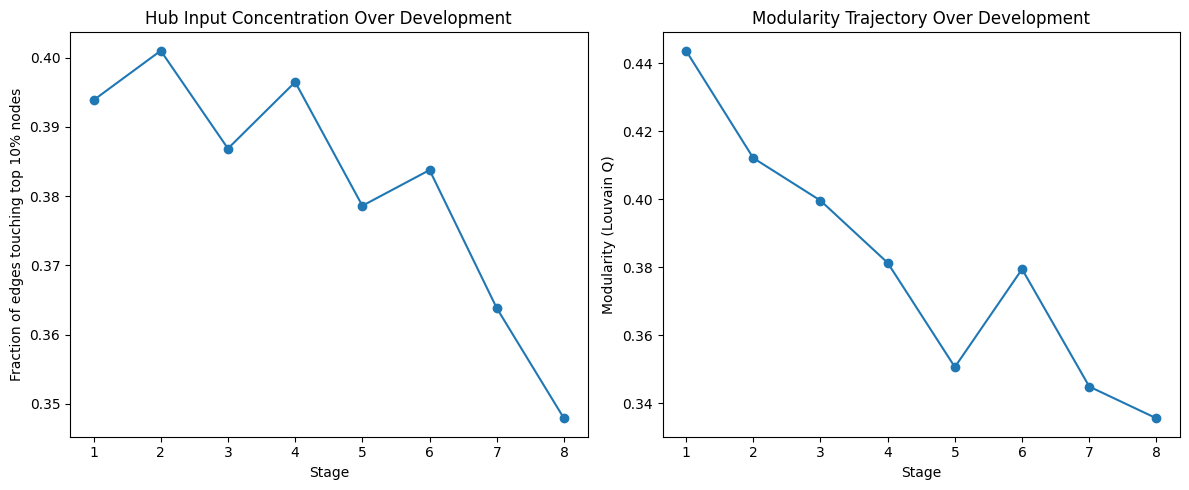


Results Table:
   stage  hub_concentration  modularity
0      1           0.393862    0.443709
1      2           0.401005    0.412140
2      3           0.386869    0.399622
3      4           0.396479    0.381310
4      5           0.378603    0.350646
5      6           0.383766    0.379448
6      7           0.363807    0.344894
7      8           0.347889    0.335548


In [ ]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import community as community_louvain  # pip install python-louvain

# ----------------------------------------------------
# Build Graph
# ----------------------------------------------------
def build_graph(stage):
    file = f"witvliet_2020_{stage}.xlsx"
    df = pd.read_excel(file)

    G = nx.DiGraph()
    for _, row in df.iterrows():
        G.add_edge(row["pre"], row["post"])

    G = G.to_undirected()

    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()

    return G

# ----------------------------------------------------
# Compute Metrics Across Stages
# ----------------------------------------------------

stages = []
hub_concentration = []
modularity_values = []

for stage in range(1,9):

    print(f"Processing Stage {stage}")

    G = build_graph(stage)

    # -------- HUB CONCENTRATION --------
    degrees = dict(G.degree())
    total_edges = G.number_of_edges()

    # sort nodes by degree
    sorted_nodes = sorted(degrees, key=degrees.get, reverse=True)

    top_k = int(0.1 * len(sorted_nodes))  # top 10%
    top_nodes = sorted_nodes[:top_k]

    # count edges incident to top nodes
    edges_top = 0
    for u,v in G.edges():
        if u in top_nodes or v in top_nodes:
            edges_top += 1

    concentration = edges_top / total_edges

    # -------- MODULARITY --------
    partition = community_louvain.best_partition(G)
    modularity = community_louvain.modularity(partition, G)

    # store
    stages.append(stage)
    hub_concentration.append(concentration)
    modularity_values.append(modularity)

# ----------------------------------------------------
# Plot Results
# ----------------------------------------------------

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(stages, hub_concentration, marker='o')
plt.xlabel("Stage")
plt.ylabel("Fraction of edges touching top 10% nodes")
plt.title("Hub Input Concentration Over Development")

plt.subplot(1,2,2)
plt.plot(stages, modularity_values, marker='o')
plt.xlabel("Stage")
plt.ylabel("Modularity (Louvain Q)")
plt.title("Modularity Trajectory Over Development")

plt.tight_layout()
plt.show()

# Print numeric results
results_df = pd.DataFrame({
    "stage": stages,
    "hub_concentration": hub_concentration,
    "modularity": modularity_values
})

print("\nResults Table:")
print(results_df)

Processing Stage 1
Processing Stage 2
Processing Stage 3
Processing Stage 4
Processing Stage 5
Processing Stage 6
Processing Stage 7
Processing Stage 8


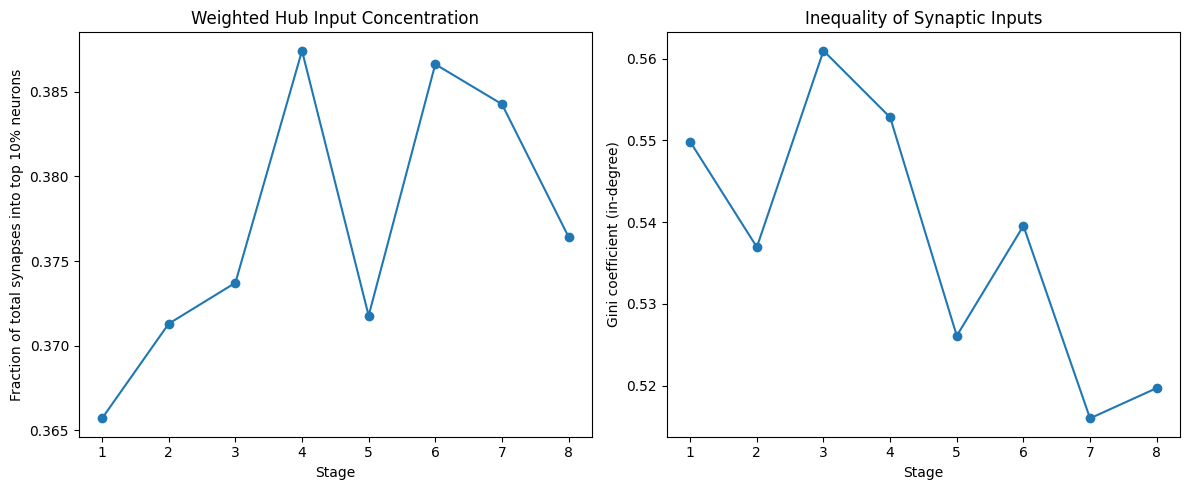


Directed Weighted Hub Results:
   stage  total_synapses  hub_input_fraction  gini_in_degree
0      1            1400            0.365714        0.549817
1      2            2028            0.371302        0.536936
2      3            2237            0.373715        0.560954
3      4            3020            0.387417        0.552805
4      5            4535            0.371775        0.526092
5      6            4723            0.386619        0.539538
6      7            7867            0.384263        0.515997
7      8            8400            0.376429        0.519696


In [ ]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------
# Build Directed Weighted Graph
# ----------------------------------------------------
def build_directed_graph(stage):
    file = f"witvliet_2020_{stage}.xlsx"
    df = pd.read_excel(file)

    G = nx.DiGraph()

    for _, row in df.iterrows():
        pre = row["pre"]
        post = row["post"]
        weight = row["synapses"]

        if G.has_edge(pre, post):
            G[pre][post]["weight"] += weight
        else:
            G.add_edge(pre, post, weight=weight)

    return G

# ----------------------------------------------------
# Gini Coefficient Function
# ----------------------------------------------------
def gini(array):
    array = np.array(array)
    if np.amin(array) < 0:
        array -= np.amin(array)
    array = array + 1e-9
    array = np.sort(array)
    index = np.arange(1, array.shape[0] + 1)
    n = array.shape[0]
    return ((np.sum((2 * index - n - 1) * array)) / (n * np.sum(array)))

# ----------------------------------------------------
# Compute Across Stages
# ----------------------------------------------------

stages = []
hub_input_fraction = []
gini_values = []
total_synapses_list = []

for stage in range(1,9):

    print(f"Processing Stage {stage}")

    G = build_directed_graph(stage)

    # Weighted in-degree
    in_degrees = dict(G.in_degree(weight="weight"))

    total_synapses = sum(in_degrees.values())

    # Sort neurons by in-degree
    sorted_nodes = sorted(in_degrees, key=in_degrees.get, reverse=True)

    top_k = int(0.1 * len(sorted_nodes))  # top 10%
    top_nodes = sorted_nodes[:top_k]

    # Sum synapses entering top nodes
    top_input_sum = sum(in_degrees[n] for n in top_nodes)

    fraction = top_input_sum / total_synapses

    # Gini coefficient
    gini_coeff = gini(list(in_degrees.values()))

    # Store
    stages.append(stage)
    hub_input_fraction.append(fraction)
    gini_values.append(gini_coeff)
    total_synapses_list.append(total_synapses)

# ----------------------------------------------------
# Plot Results
# ----------------------------------------------------

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(stages, hub_input_fraction, marker='o')
plt.xlabel("Stage")
plt.ylabel("Fraction of total synapses into top 10% neurons")
plt.title("Weighted Hub Input Concentration")

plt.subplot(1,2,2)
plt.plot(stages, gini_values, marker='o')
plt.xlabel("Stage")
plt.ylabel("Gini coefficient (in-degree)")
plt.title("Inequality of Synaptic Inputs")

plt.tight_layout()
plt.show()

# Display table
results_df = pd.DataFrame({
    "stage": stages,
    "total_synapses": total_synapses_list,
    "hub_input_fraction": hub_input_fraction,
    "gini_in_degree": gini_values
})

print("\nDirected Weighted Hub Results:")
print(results_df)